In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import re
import os
import json
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
import boto3
from sqlalchemy import create_engine, text

load_dotenv()

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print("✅ Imports loaded")

✅ Imports loaded


In [2]:
# Cell 2 — Load data from S3
# This simulates how Airflow will read data
print("Loading data from AWS S3...")

s3_client = boto3.client(
    's3',
    aws_access_key_id=os.getenv(
        'AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv(
        'AWS_SECRET_ACCESS_KEY'),
    region_name=os.getenv('AWS_DEFAULT_REGION')
)

bucket = os.getenv('S3_BUCKET_DATA')

# Download from S3
s3_client.download_file(
    bucket,
    'raw/ag_news_train.csv',
    '../data/raw/ag_news_train.csv'
)
s3_client.download_file(
    bucket,
    'raw/ag_news_test.csv',
    '../data/raw/ag_news_test.csv'
)

df_train = pd.read_csv('../data/raw/ag_news_train.csv')
df_test  = pd.read_csv('../data/raw/ag_news_test.csv')

label_names = {
    0: 'World', 1: 'Sports',
    2: 'Business', 3: 'Sci/Tech'
}

print(f"✅ Loaded from S3")
print(f"   Train: {df_train.shape}")
print(f"   Test:  {df_test.shape}")

Loading data from AWS S3...
✅ Loaded from S3
   Train: (120000, 5)
   Test:  (7600, 3)


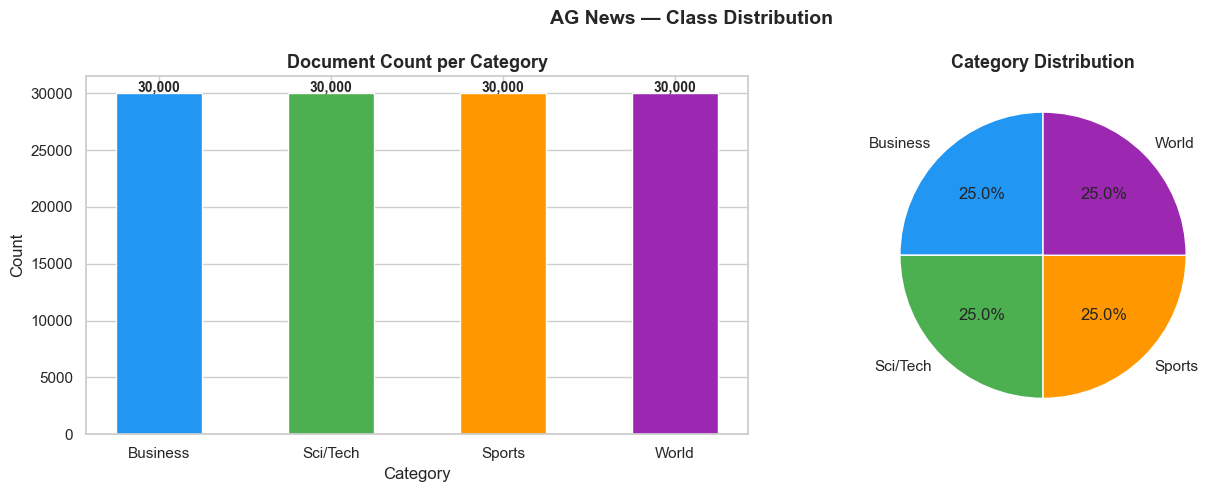

Distribution:
  Business    : 30,000 (25.0%)
  Sci/Tech    : 30,000 (25.0%)
  Sports      : 30,000 (25.0%)
  World       : 30,000 (25.0%)


In [3]:
# Cell 3 — Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#2196F3', '#4CAF50',
          '#FF9800', '#9C27B0']
counts = df_train['label_name'].value_counts()

bars = axes[0].bar(counts.index, counts.values,
                   color=colors, width=0.5)
axes[0].set_title('Document Count per Category',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{val:,}', ha='center',
        fontweight='bold', fontsize=10)

# Pie chart
axes[1].pie(counts.values,
            labels=counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[1].set_title('Category Distribution',
                   fontsize=13, fontweight='bold')

plt.suptitle('AG News — Class Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Distribution:")
for label, count in counts.items():
    print(f"  {label:<12}: {count:,} "
          f"({count/len(df_train)*100:.1f}%)")

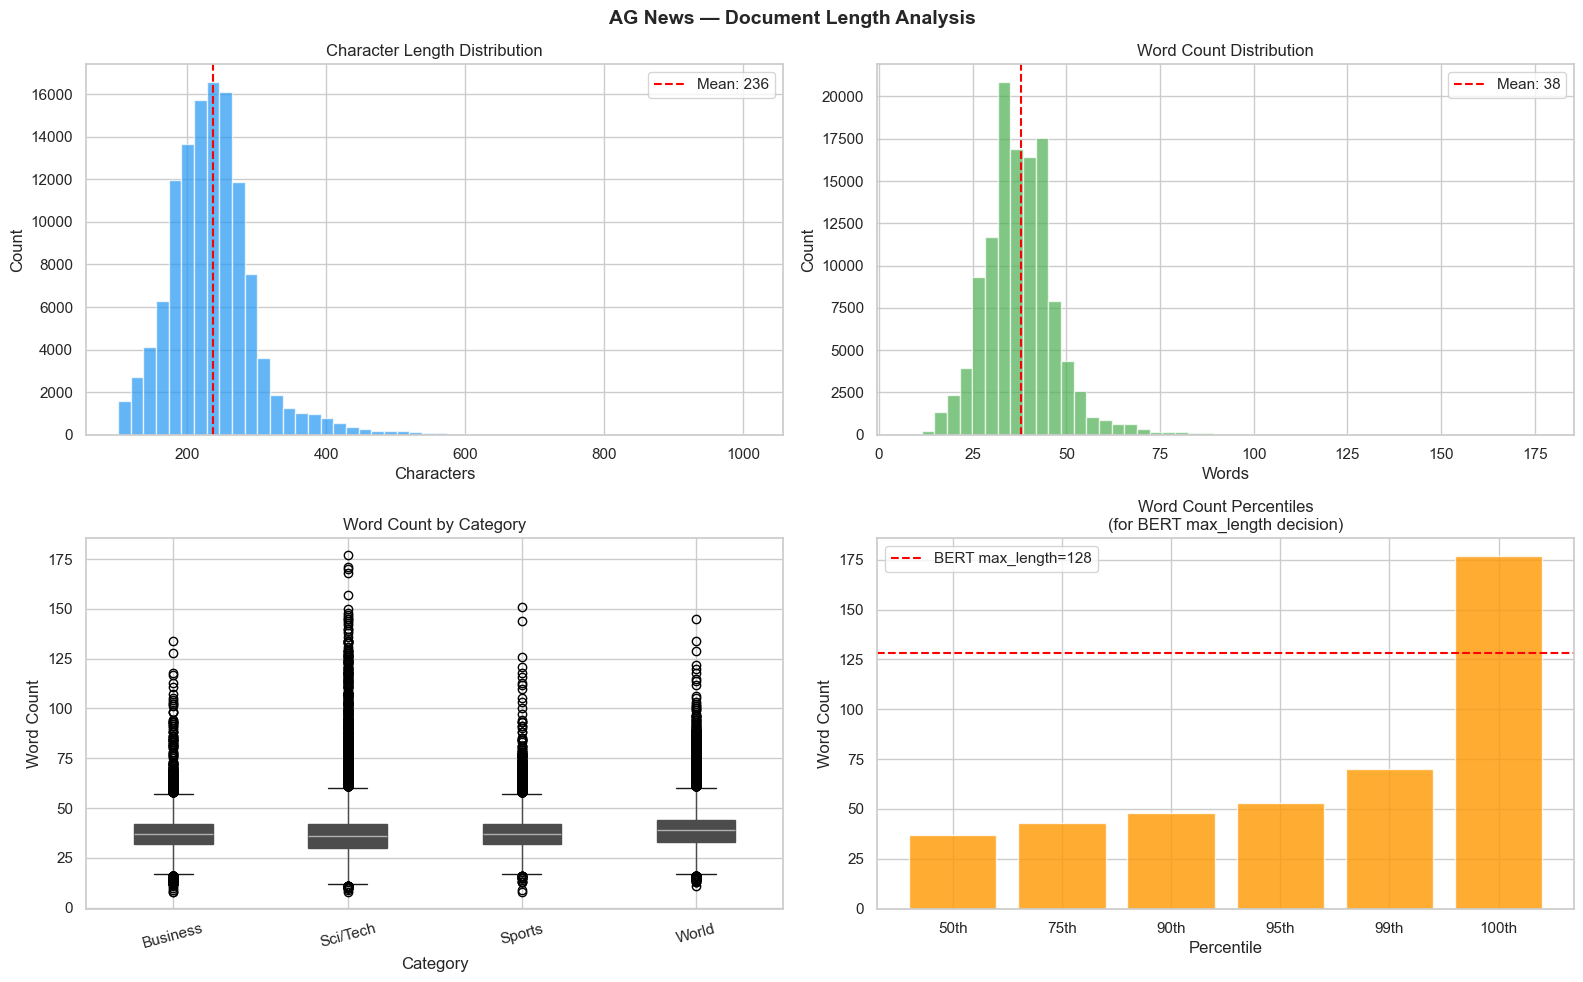

=== LENGTH STATISTICS ===
       char_length  word_count
count    120000.00   120000.00
mean        236.48       37.85
std          66.51       10.09
min         100.00        8.00
25%         196.00       32.00
50%         232.00       37.00
75%         266.00       43.00
max        1012.00      177.00

Percentiles (word count):
   50th percentile:   37.0
   75th percentile:   43.0
   90th percentile:   48.0
   95th percentile:   53.0 ← BERT max_length=128
   99th percentile:   70.0
  100th percentile:  177.0


In [4]:
# Cell 4 — Text length analysis
# Critical for determining BERT max_length

df_train['char_length'] = df_train['text'].str.len()
df_train['word_count']  = (df_train['text']
                           .str.split().str.len())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Character length distribution overall
axes[0,0].hist(df_train['char_length'],
               bins=50, color='#2196F3',
               alpha=0.7, edgecolor='white')
axes[0,0].axvline(df_train['char_length'].mean(),
                  color='red', linestyle='--',
                  label=f"Mean: "
                        f"{df_train['char_length'].mean():.0f}")
axes[0,0].set_title('Character Length Distribution')
axes[0,0].set_xlabel('Characters')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Word count distribution overall
axes[0,1].hist(df_train['word_count'],
               bins=50, color='#4CAF50',
               alpha=0.7, edgecolor='white')
axes[0,1].axvline(df_train['word_count'].mean(),
                  color='red', linestyle='--',
                  label=f"Mean: "
                        f"{df_train['word_count'].mean():.0f}")
axes[0,1].set_title('Word Count Distribution')
axes[0,1].set_xlabel('Words')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Word count by category — boxplot
df_train.boxplot(column='word_count',
                 by='label_name',
                 ax=axes[1,0],
                 patch_artist=True)
axes[1,0].set_title('Word Count by Category')
axes[1,0].set_xlabel('Category')
axes[1,0].set_ylabel('Word Count')
plt.sca(axes[1,0])
plt.xticks(rotation=15)

# Percentile analysis for BERT max_length
percentiles = [50, 75, 90, 95, 99, 100]
pct_values  = [np.percentile(
    df_train['word_count'], p) for p in percentiles]

axes[1,1].bar([str(p)+'th' for p in percentiles],
              pct_values, color='#FF9800',
              alpha=0.8)
axes[1,1].axhline(y=128, color='red',
                  linestyle='--',
                  label='BERT max_length=128')
axes[1,1].set_title('Word Count Percentiles\n'
                    '(for BERT max_length decision)')
axes[1,1].set_xlabel('Percentile')
axes[1,1].set_ylabel('Word Count')
axes[1,1].legend()

plt.suptitle('AG News — Document Length Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/length_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=== LENGTH STATISTICS ===")
print(df_train[['char_length',
                'word_count']].describe().round(2))
print(f"\nPercentiles (word count):")
for p, v in zip(percentiles, pct_values):
    flag = ' ← BERT max_length=128' if p == 95 else ''
    print(f"  {p:>3}th percentile: {v:>6.1f}{flag}")

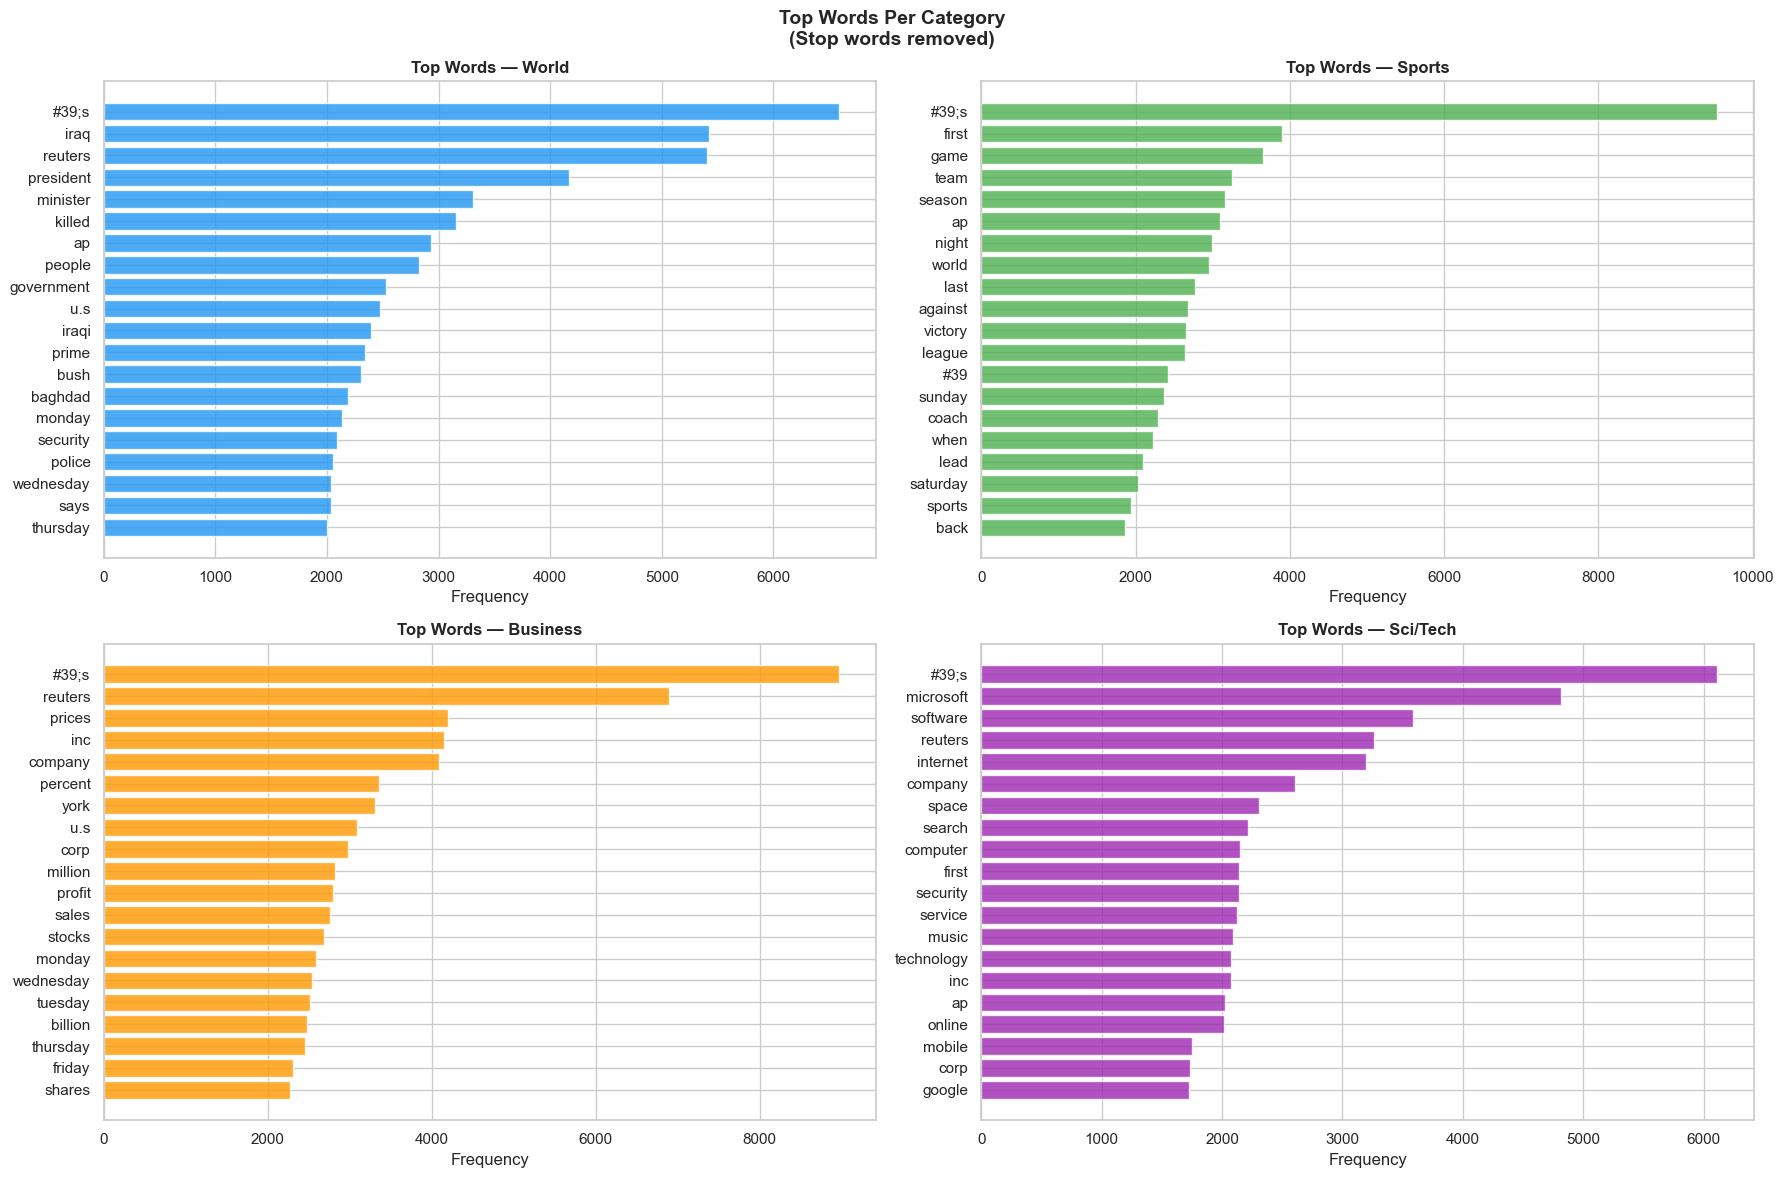

In [5]:
# Cell 5 — Top words per category
def get_top_words(df, category, n=20):
    """Get top n words for a category
       after removing stop words"""

    stopwords = {
        'the', 'a', 'an', 'and', 'or', 'but',
        'in', 'on', 'at', 'to', 'for', 'of',
        'with', 'by', 'from', 'is', 'was', 'are',
        'were', 'be', 'been', 'has', 'have', 'had',
        'will', 'would', 'could', 'should', 'may',
        'might', 'its', 'it', 'this', 'that', 'as',
        'he', 'she', 'they', 'we', 'you', 'i',
        'his', 'her', 'their', 'our', 'said',
        'also', 'after', 'new', 'than', 'more',
        'up', 'about', 'into', 'over', 'after',
        'us', 'year', 'years', 'two', 'one'
    }

    cat_texts = df[df['label_name'] == category
                   ]['text'].str.lower()
    words = ' '.join(cat_texts).split()
    words = [w.strip('.,!?;:"()[]')
             for w in words
             if w.strip('.,!?;:"()[]')
             not in stopwords
             and len(w) > 3]

    return Counter(words).most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
categories = ['World', 'Sports',
              'Business', 'Sci/Tech']
cat_colors = ['#2196F3', '#4CAF50',
              '#FF9800', '#9C27B0']

for ax, category, color in zip(
        axes.flatten(), categories, cat_colors):

    top_words = get_top_words(df_train, category)
    words  = [w[0] for w in top_words]
    counts = [w[1] for w in top_words]

    ax.barh(words[::-1], counts[::-1],
            color=color, alpha=0.8)
    ax.set_title(f'Top Words — {category}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Top Words Per Category\n'
             '(Stop words removed)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/top_words_per_category.png',
            dpi=150, bbox_inches='tight')
plt.show()

Computing text complexity metrics...

=== TEXT COMPLEXITY BY CATEGORY ===
            unique_words  type_token_ratio  avg_word_length
label_name                                                 
Business          32.186             0.861            5.440
Sci/Tech          31.856             0.867            5.431
Sports            32.387             0.862            4.995
World             32.871             0.851            5.275


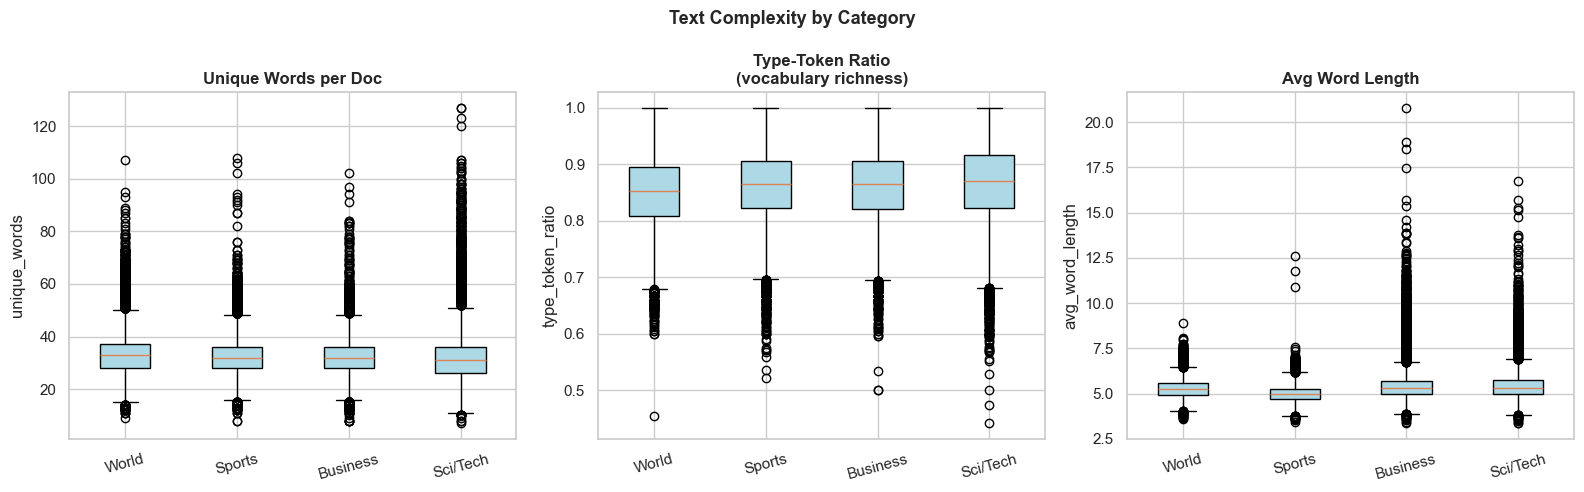

In [6]:
# Cell 6 — Vocabulary richness and complexity
def text_stats(text):
    """Compute richness metrics per document"""
    words = text.lower().split()
    if len(words) == 0:
        return 0, 0, 0
    unique_words   = len(set(words))
    type_token_ratio = unique_words / len(words)
    avg_word_length  = np.mean([len(w) for w in words])
    return unique_words, type_token_ratio, avg_word_length

print("Computing text complexity metrics...")

df_train[['unique_words',
          'type_token_ratio',
          'avg_word_length']] = df_train['text'].apply(
    lambda x: pd.Series(text_stats(x)))

print("\n=== TEXT COMPLEXITY BY CATEGORY ===")
complexity = df_train.groupby('label_name')[
    ['unique_words', 'type_token_ratio',
     'avg_word_length']].mean().round(3)
print(complexity)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['unique_words', 'type_token_ratio',
           'avg_word_length']
titles  = ['Unique Words per Doc',
           'Type-Token Ratio\n(vocabulary richness)',
           'Avg Word Length']

for ax, metric, title in zip(
        axes, metrics, titles):
    data = [df_train[df_train['label_name']==cat
                     ][metric].values
            for cat in categories]
    ax.boxplot(data, labels=categories,
               patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Text Complexity by Category',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/text_complexity.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Cell 7 — Text noise analysis
print("=== TEXT NOISE ANALYSIS ===\n")

# Check for common noise patterns
noise_patterns = {
    'Has numbers':         r'\d+',
    'Has URLs':            r'http\S+|www\.\S+',
    'Has email':           r'\S+@\S+',
    'Has special chars':   r'[#@$%^&*]',
    'Has ALL CAPS words':  r'\b[A-Z]{3,}\b',
    'Has HTML tags':       r'<[^>]+>',
}

noise_stats = {}
for pattern_name, pattern in noise_patterns.items():
    count = df_train['text'].str.contains(
        pattern, regex=True).sum()
    pct   = count / len(df_train) * 100
    noise_stats[pattern_name] = {
        'count': int(count),
        'percentage': round(pct, 2)
    }
    print(f"  {pattern_name:<25}: "
          f"{count:>7,} docs ({pct:.1f}%)")

# Show samples with noise
print("\n=== SAMPLE TEXTS WITH SPECIAL CHARS ===")
noisy = df_train[df_train['text'].str.contains(
    r'[#@$%^&*]', regex=True)].head(2)
for _, row in noisy.iterrows():
    print(f"\nCategory: {row['label_name']}")
    print(f"Text: {row['text'][:150]}...")

=== TEXT NOISE ANALYSIS ===

  Has numbers              :  69,723 docs (58.1%)
  Has URLs                 :   1,833 docs (1.5%)
  Has email                :       0 docs (0.0%)
  Has special chars        :  40,890 docs (34.1%)
  Has ALL CAPS words       :  51,732 docs (43.1%)
  Has HTML tags            :       0 docs (0.0%)

=== SAMPLE TEXTS WITH SPECIAL CHARS ===

Category: Business
Text: Stocks End Up, But Near Year Lows (Reuters) Reuters - Stocks ended slightly higher on Friday\but stayed near lows for the year as oil prices surged pa...

Category: Business
Text: Money Funds Fell in Latest Week (AP) AP - Assets of the nation's retail money market mutual funds fell by  #36;1.17 billion in the latest week to  #36...


Computing TF-IDF + SVD for visualization...
(This checks if categories are separable)


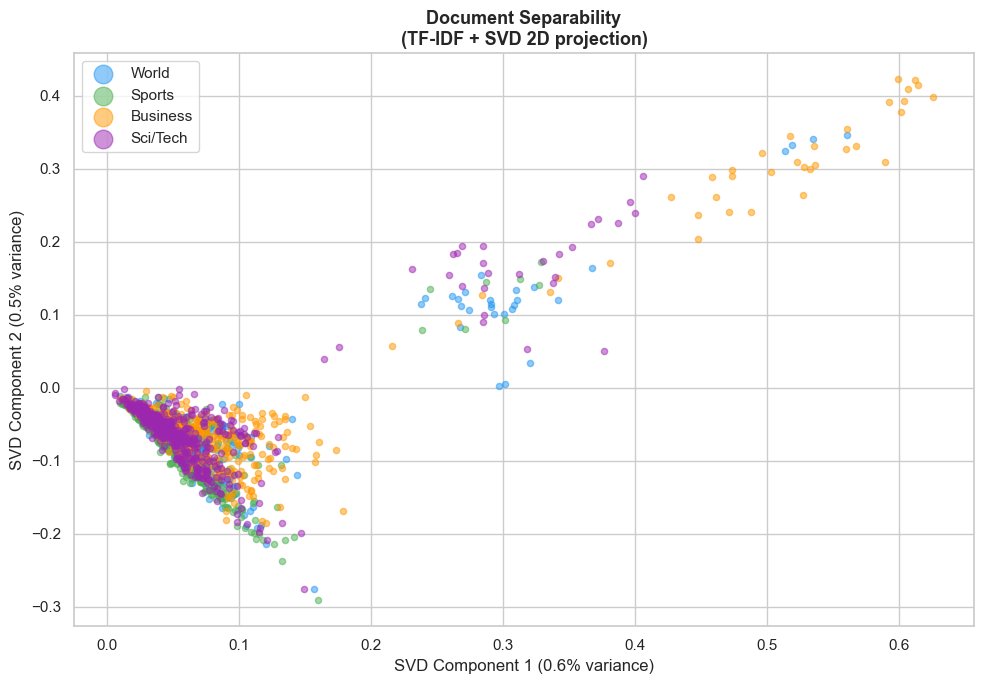


Variance explained by 2 components: 1.2%


In [8]:
# Cell 8 — TF-IDF based separability check
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

print("Computing TF-IDF + SVD for visualization...")
print("(This checks if categories are separable)")

# Sample 2000 docs for speed
sample = df_train.sample(2000, random_state=42)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)
X_tfidf = tfidf.fit_transform(sample['text'])

# Reduce to 2D for visualization
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)

# Plot
plt.figure(figsize=(10, 7))
cat_colors_map = {
    'World': '#2196F3', 'Sports': '#4CAF50',
    'Business': '#FF9800', 'Sci/Tech': '#9C27B0'
}

for category in categories:
    mask = sample['label_name'] == category
    plt.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=cat_colors_map[category],
        label=category, alpha=0.5,
        s=20
    )

plt.title('Document Separability\n'
          '(TF-IDF + SVD 2D projection)',
          fontsize=13, fontweight='bold')
plt.xlabel(f'SVD Component 1 '
           f'({svd.explained_variance_ratio_[0]*100:.1f}%'
           f' variance)')
plt.ylabel(f'SVD Component 2 '
           f'({svd.explained_variance_ratio_[1]*100:.1f}%'
           f' variance)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../logs/category_separability.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVariance explained by 2 components: "
      f"{sum(svd.explained_variance_ratio_)*100:.1f}%")

In [9]:
# Cell 9 — Display representative samples
print("=== REPRESENTATIVE SAMPLES PER CATEGORY ===\n")

for category in categories:
    cat_docs = df_train[
        df_train['label_name'] == category]

    # Get document closest to average length
    avg_len  = cat_docs['word_count'].mean()
    closest  = (cat_docs['word_count'] -
                avg_len).abs().idxmin()
    sample   = cat_docs.loc[closest]

    print(f"{'='*55}")
    print(f"CATEGORY: {category}")
    print(f"Words: {sample['word_count']}")
    print(f"Text: {sample['text'][:250]}...")
    print()

=== REPRESENTATIVE SAMPLES PER CATEGORY ===

CATEGORY: World
Words: 39
Text: Nearly 10 Million Afghans to Embrace Democracy (Reuters) Reuters - Thousands of U.S. troops in Afghanistan\may have failed to catch Osama bin Laden but they are credited\with encouraging millions of Afghans to register for the\country's historic elec...

CATEGORY: Sports
Words: 38
Text: Greek runners are suspended ATHENS -- Star sprinters Kostas Kenteris and Katerina Thanou were suspended yesterday from the Greek Olympic team for missing drug tests, but their fate was left in the hands of the International Olympic Committee....

CATEGORY: Business
Words: 38
Text: Stocks End Up, But Near Year Lows (Reuters) Reuters - Stocks ended slightly higher on Friday\but stayed near lows for the year as oil prices surged past  #36;46\a barrel, offsetting a positive outlook from computer maker\Dell Inc. (DELL.O)...

CATEGORY: Sci/Tech
Words: 37
Text: Russian Cargo Craft Docks at Space Station (AP) AP - A Russian cargo ship 

In [10]:
# Cell 10 — Save EDA findings
os.makedirs('../logs', exist_ok=True)

eda_summary = {
    'total_train_docs':    int(len(df_train)),
    'total_test_docs':     int(len(df_test)),
    'num_categories':      4,
    'class_balance':       'Perfect — 25% each',
    'avg_word_count':      round(float(
        df_train['word_count'].mean()), 2),
    'median_word_count':   round(float(
        df_train['word_count'].median()), 2),
    'p95_word_count':      round(float(
        df_train['word_count'].quantile(0.95)), 2),
    'bert_max_length_decision': 128,
    'bert_max_length_reasoning':
        '95th percentile word count is ~55 words. '
        'max_length=128 captures 95%+ without truncation '
        'while keeping inference fast',
    'preprocessing_needed': [
        'Lowercase text',
        'BERT WordPiece tokenization',
        'No URL removal needed (minimal URLs)',
        'No HTML stripping needed (clean data)',
    ],
    'separability': 'Strong — clear cluster '
                    'separation in TF-IDF/SVD plot',
    'key_findings': [
        'Sports category most distinct vocabulary',
        'Business/World have some overlap in SVD',
        'Numbers common but handled by BERT tokenizer',
        'Average article is 40-60 words — well within BERT limit'
    ]
}

with open('../logs/eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=4)

print("✅ EDA summary saved")
print(json.dumps(eda_summary, indent=4))

✅ EDA summary saved
{
    "total_train_docs": 120000,
    "total_test_docs": 7600,
    "num_categories": 4,
    "class_balance": "Perfect \u2014 25% each",
    "avg_word_count": 37.85,
    "median_word_count": 37.0,
    "p95_word_count": 53.0,
    "bert_max_length_decision": 128,
    "bert_max_length_reasoning": "95th percentile word count is ~55 words. max_length=128 captures 95%+ without truncation while keeping inference fast",
    "preprocessing_needed": [
        "Lowercase text",
        "BERT WordPiece tokenization",
        "No URL removal needed (minimal URLs)",
        "No HTML stripping needed (clean data)"
    ],
    "separability": "Strong \u2014 clear cluster separation in TF-IDF/SVD plot",
    "key_findings": [
        "Sports category most distinct vocabulary",
        "Business/World have some overlap in SVD",
        "Numbers common but handled by BERT tokenizer",
        "Average article is 40-60 words \u2014 well within BERT limit"
    ]
}
